# Phase 3 Day 2: 統計的検証と考察

**目的**: Day 1 で得た「Metal ARI < Rubber ARI」「DINOv1 > DINOv2」等の結果について、  
統計的に何が言えて何が言えないかを、コード付きで一つずつ確認する。

**前提**: 
- ラベルバグ（`np.random.rand() < 0.3`）を修正し、正しい `material_label` で300サンプルを再取得済み
- 3 backbone（DINOv2/DINOv1/CLIP）の推論結果は `results/ari_v2_*.json` に保存済み
- モデルは60サンプルで訓練済み。300サンプルは評価のみ（再訓練なし）

**このノートブックで確認すること**:
1. データの信頼性（ラベルが本当に正しいか）
2. 各結果が統計的に有意か
3. 有意でない場合、なぜか（検出力不足？効果なし？）
4. ポスターで何を主張でき、何を主張できないか

## 1. ライブラリのインポートとデータ読み込み

3モデルの推論結果（`results/ari_v2_*.json`）を読み込み、1つの DataFrame にまとめる。

各列の意味:
- `filename`: シーンファイル名（scene_0000.pt 〜 scene_0299.pt）
- `scene_type`: シーン内の材質構成（mixed / metal_only / rubber_only）
- `metal_count`, `rubber_count`: そのシーン内の metal / rubber オブジェクト数
- `fg_ari`: Foreground ARI（背景を除く全オブジェクトの分離精度）
- `metal_ari`: metal オブジェクトのピクセルのみで計算した ARI
- `rubber_ari`: rubber オブジェクトのピクセルのみで計算した ARI

**NaN について**: `metal_ari` や `rubber_ari` が NaN になるケースがある。  
これは「その材質のオブジェクトが1個しかない」場面で、ARI の計算に最低2つのGTインスタンスが必要なため。

In [1]:
import json
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# --- 3モデルの結果を読み込み ---
models = {}
for name in ['dinov2', 'dinov1', 'clip']:
    with open(f'../results/ari_v2_{name}.json') as f:
        models[name] = json.load(f)

# --- per_sample を DataFrame に変換 ---
rows = []
for name, data in models.items():
    for s in data['per_sample']:
        rows.append({
            'model': name,
            'filename': s['filename'],
            'scene_type': s['scene_type'],
            'metal_count': s['metal_count'],
            'rubber_count': s['rubber_count'],
            'fg_ari': s['fg_ari'],
            'metal_ari': s['metal_ari'],
            'rubber_ari': s['rubber_ari'],
        })

df = pd.DataFrame(rows)

# NaN を正しく処理（JSON の null や float('nan') 両方に対応）
df['metal_ari'] = pd.to_numeric(df['metal_ari'], errors='coerce')
df['rubber_ari'] = pd.to_numeric(df['rubber_ari'], errors='coerce')

print(f"行数: {len(df)} (= 3モデル × 300シーン)")
print(f"モデル: {df['model'].unique().tolist()}")
print(f"\n--- 先頭5行（DINOv2） ---")
df[df['model'] == 'dinov2'].head()

行数: 900 (= 3モデル × 300シーン)
モデル: ['dinov2', 'dinov1', 'clip']

--- 先頭5行（DINOv2） ---


,model,filename,scene_type,metal_count,rubber_count,fg_ari,metal_ari,rubber_ari
0,dinov2,scene_0000.pt,mixed,2,6,0.162290,NaN,0.176970
1,dinov2,scene_0001.pt,mixed,2,3,0.169878,0.160000,0.250000
2,dinov2,scene_0002.pt,mixed,5,1,0.178187,0.123228,NaN
3,dinov2,scene_0003.pt,mixed,2,2,0.231746,-0.153846,-0.166667
4,dinov2,scene_0004.pt,mixed,5,3,0.118136,0.169469,0.077307


## 2. 材質ラベル問題の再確認：何が間違っていたか

旧 `download_movi.py` L88 のバグ:
```python
is_metal_only = np.random.rand() < 0.3  # ← 実データと無関係にランダム
```

これは **シーンレベル** で30%を "metal" と分類しただけ。  
オブジェクト単位の材質（metal/rubber）は一切参照していなかった。

**結果**: 旧 Table 2 の "Metal FG-ARI" vs "Non-metal FG-ARI" は、  
「ランダムに分けた2群の比較」に過ぎず、材質の影響を一切反映していない。

以下のセルで、ランダムラベルがどれほど実際のラベルと乖離するかを確認する。

=== 正しいラベル（TFDS material_label） ===
  metal_only: 8 (2.7%)
  rubber_only: 5 (1.7%)
  mixed:       287 (95.7%)

=== ランダムラベル（旧コード再現, 1000回シミュレーション） ===
  'metal' に分類される割合: 0.299 ± 0.026
  つまり約30%のシーンが無作為に 'metal' とラベル付けされる

  実際の metal_only シーンは 2.7% しかないのに、
  ランダムラベルは 30% を metal とするため、大半が誤分類


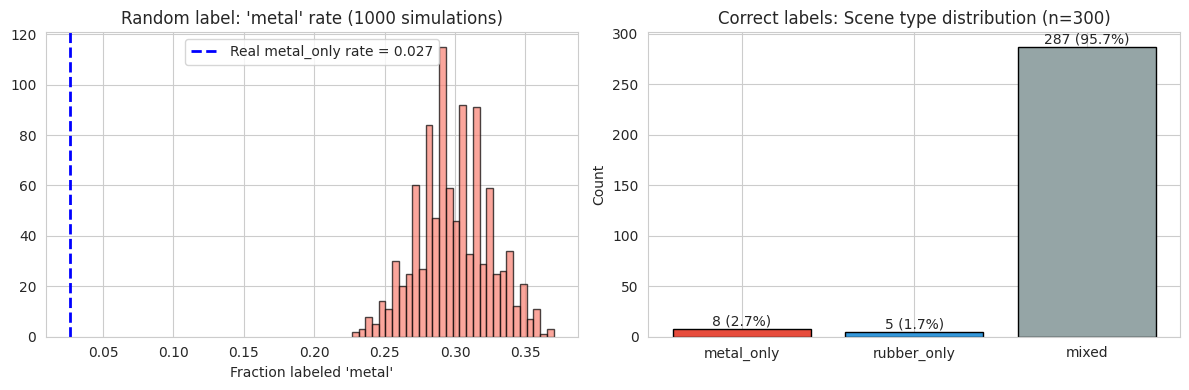


★ 要点: ランダムラベルは ~30% を metal_only とするが、実際は 2.7% しかない。
  旧 Table 2 は「30% vs 70% のランダム分割の比較」であり、材質の効果を一切反映していなかった。


In [2]:
# --- ランダムラベル vs 正しいラベルのシミュレーション ---
# 正しいラベル: 300シーンの実際の scene_type 分布
d2 = df[df['model'] == 'dinov2'].copy()
real_metal_only = (d2['scene_type'] == 'metal_only').sum()
real_rubber_only = (d2['scene_type'] == 'rubber_only').sum()
real_mixed = (d2['scene_type'] == 'mixed').sum()

print("=== 正しいラベル（TFDS material_label） ===")
print(f"  metal_only: {real_metal_only} ({real_metal_only/300*100:.1f}%)")
print(f"  rubber_only: {real_rubber_only} ({real_rubber_only/300*100:.1f}%)")
print(f"  mixed:       {real_mixed} ({real_mixed/300*100:.1f}%)")

# ランダムラベル: np.random.rand() < 0.3 のシミュレーション（1000回）
np.random.seed(42)
n_simulations = 1000
random_metal_fracs = [np.mean(np.random.rand(300) < 0.3) for _ in range(n_simulations)]

print(f"\n=== ランダムラベル（旧コード再現, 1000回シミュレーション） ===")
print(f"  'metal' に分類される割合: {np.mean(random_metal_fracs):.3f} ± {np.std(random_metal_fracs):.3f}")
print(f"  つまり約30%のシーンが無作為に 'metal' とラベル付けされる")
print(f"\n  実際の metal_only シーンは {real_metal_only/300*100:.1f}% しかないのに、")
print(f"  ランダムラベルは 30% を metal とするため、大半が誤分類")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左: ランダムラベルでの metal 割合分布
axes[0].hist(random_metal_fracs, bins=30, color='salmon', alpha=0.7, edgecolor='black')
axes[0].axvline(real_metal_only/300, color='blue', linewidth=2, linestyle='--', 
                label=f'Real metal_only rate = {real_metal_only/300:.3f}')
axes[0].set_title("Random label: 'metal' rate (1000 simulations)")
axes[0].set_xlabel("Fraction labeled 'metal'")
axes[0].legend()

# 右: 正しいラベルでのシーン分類
cats = ['metal_only', 'rubber_only', 'mixed']
vals = [real_metal_only, real_rubber_only, real_mixed]
colors = ['#e74c3c', '#3498db', '#95a5a6']
bars = axes[1].bar(cats, vals, color=colors, edgecolor='black')
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                 f'{v} ({v/300*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_title("Correct labels: Scene type distribution (n=300)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\n★ 要点: ランダムラベルは ~30% を metal_only とするが、実際は 2.7% しかない。")
print("  旧 Table 2 は「30% vs 70% のランダム分割の比較」であり、材質の効果を一切反映していなかった。")

## 3. データの信頼性確認：friction による独立検証

材質ラベルが正しいことを、**friction（摩擦係数）** で交差検証する。

MOVi-A の Kubric 設定:
- **Metal**: friction = 0.4 （低摩擦 = 滑りやすい）
- **Rubber**: friction = 0.8 （高摩擦 = グリップ力あり）

もし `material_label` が正しいなら、friction 値とラベルは完全に対応するはずである。  
（Day 1 で全300サンプル PASS を確認済みだが、ここで自分の目でも確認する。）

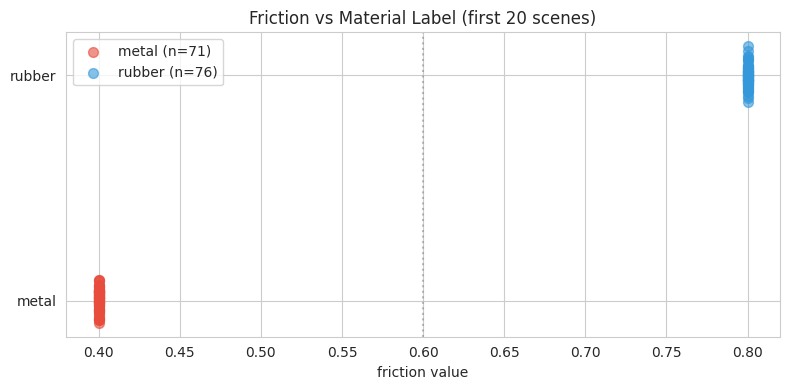


全 1969 オブジェクト中、friction とラベルの不一致: 0
→ ✅ 全件一致。ラベルは信頼できる。


In [3]:
import torch
from pathlib import Path

# --- 最初の20サンプルで friction cross-check ---
data_dir = Path("../data/movi_a_v2")
samples = sorted(data_dir.glob("scene_*.pt"))[:20]

check_rows = []
for sp in samples:
    d = torch.load(sp, weights_only=False)
    materials = d['materials']  # list of 'metal' or 'rubber'
    frictions = d['friction']   # list of float
    for mat, fric in zip(materials, frictions):
        check_rows.append({'file': sp.name, 'material': mat, 'friction': fric})

check_df = pd.DataFrame(check_rows)

# 散布図（実際にはカテゴリカルだが、分布を見るため jitter を入れる）
fig, ax = plt.subplots(figsize=(8, 4))
for mat, color in [('metal', '#e74c3c'), ('rubber', '#3498db')]:
    subset = check_df[check_df['material'] == mat]
    ax.scatter(subset['friction'], 
               np.random.normal(0, 0.05, len(subset)) + (0 if mat == 'metal' else 1),
               color=color, alpha=0.6, label=f'{mat} (n={len(subset)})', s=50)

ax.set_xlabel('friction value')
ax.set_yticks([0, 1])
ax.set_yticklabels(['metal', 'rubber'])
ax.set_title('Friction vs Material Label (first 20 scenes)')
ax.legend()
ax.axvline(0.6, color='gray', linestyle=':', alpha=0.5, label='boundary')
plt.tight_layout()
plt.show()

# 全量チェック
n_mismatch = 0
for sp in sorted(data_dir.glob("scene_*.pt")):
    d = torch.load(sp, weights_only=False)
    for mat, fric in zip(d['materials'], d['friction']):
        expected = 0.4 if mat == 'metal' else 0.8
        if abs(fric - expected) > 0.01:
            n_mismatch += 1
            print(f"MISMATCH: {sp.name}, {mat}, friction={fric}")

total_objects = sum(len(torch.load(sp, weights_only=False)['materials']) for sp in sorted(data_dir.glob("scene_*.pt")))
print(f"\n全 {total_objects} オブジェクト中、friction とラベルの不一致: {n_mismatch}")
print(f"→ {'✅ 全件一致。ラベルは信頼できる。' if n_mismatch == 0 else '❌ 不一致あり！要確認'}")

## 4. データ統計：300サンプルの材質分布

ここではまだモデルの結果に触れず、**データ自体の性質**だけを確認する。

確認すること:
- シーン分類分布（mixed が圧倒的に多い → per-object ARI が重要な理由）
- オブジェクト単位の metal/rubber 個数（ほぼ 50:50 か）
- シーンあたりオブジェクト数の分布

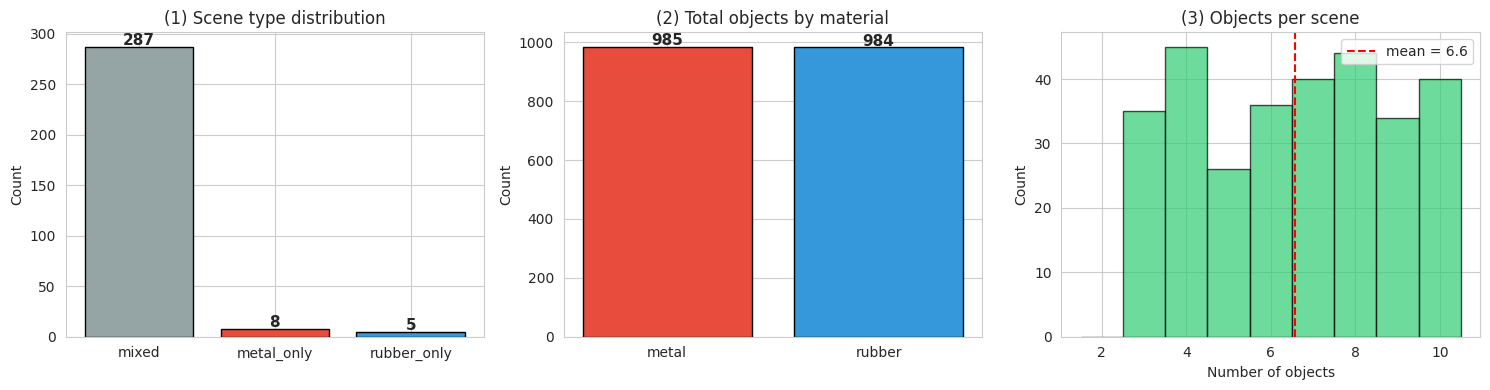

metal_only: 8シーン  → per-object ARI のみ計算可能
rubber_only: 5シーン → per-object ARI のみ計算可能
mixed: 287シーン → Metal/Rubber 両方の per-object ARI を比較可能

★ 重要: 95.7% が mixed シーン。「metal_only vs rubber_only」のシーン比較は n=8 vs n=5 で統計的に弱い。
  → per-object ARI（シーン内で材質別にピクセルを分けて計算）が主要な分析手段。


In [4]:
# DINOv2 のデータで確認（3モデルとも同じシーンを評価しているので中身は同一）
d2 = df[df['model'] == 'dinov2'].copy()
d2['total_objects'] = d2['metal_count'] + d2['rubber_count']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) シーン分類の分布
scene_counts = d2['scene_type'].value_counts()
colors_map = {'mixed': '#95a5a6', 'metal_only': '#e74c3c', 'rubber_only': '#3498db'}
bars = axes[0].bar(scene_counts.index, scene_counts.values, 
                   color=[colors_map[x] for x in scene_counts.index], edgecolor='black')
for bar, v in zip(bars, scene_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{v}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title("(1) Scene type distribution")
axes[0].set_ylabel("Count")

# (2) オブジェクト単位の metal/rubber
total_metal = d2['metal_count'].sum()
total_rubber = d2['rubber_count'].sum()
bars2 = axes[1].bar(['metal', 'rubber'], [total_metal, total_rubber], 
                    color=['#e74c3c', '#3498db'], edgecolor='black')
for bar, v in zip(bars2, [total_metal, total_rubber]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{v}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title("(2) Total objects by material")
axes[1].set_ylabel("Count")

# (3) シーンあたりオブジェクト数の分布
axes[2].hist(d2['total_objects'], bins=range(2, 12), color='#2ecc71', 
             edgecolor='black', alpha=0.7, align='left')
axes[2].axvline(d2['total_objects'].mean(), color='red', linestyle='--', 
                label=f'mean = {d2["total_objects"].mean():.1f}')
axes[2].set_title("(3) Objects per scene")
axes[2].set_xlabel("Number of objects")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"metal_only: {(d2['scene_type']=='metal_only').sum()}シーン  → per-object ARI のみ計算可能")
print(f"rubber_only: {(d2['scene_type']=='rubber_only').sum()}シーン → per-object ARI のみ計算可能")
print(f"mixed: {(d2['scene_type']=='mixed').sum()}シーン → Metal/Rubber 両方の per-object ARI を比較可能")
print(f"\n★ 重要: 95.7% が mixed シーン。「metal_only vs rubber_only」のシーン比較は n=8 vs n=5 で統計的に弱い。")
print(f"  → per-object ARI（シーン内で材質別にピクセルを分けて計算）が主要な分析手段。")

## 5. Table A 再現：3 Backbone 全体 FG-ARI 比較

全300シーンの FG-ARI を集計し、旧60サンプルの結果と比較する。

- FG-ARI は材質ラベルに**依存しない**（全前景オブジェクトを対象とするため）
- したがってラベルバグの影響を受けず、旧結果と大きく変わらないはず

注目点: DINOv1 (0.176) > DINOv2 (0.168) の逆転が観測されるが、  
これが統計的に有意かどうかは §9 で詳しく検証する。ここでは数値の確認のみ。

In [5]:
# --- Table A: 全体 FG-ARI ---
table_a = df.groupby('model')['fg_ari'].agg(['mean', 'std', 'count']).round(4)
table_a = table_a.loc[['dinov2', 'dinov1', 'clip']]  # 順序を固定

# 旧60サンプルの結果（論文提出版）
old_results = {'dinov2': 0.165, 'dinov1': 0.153, 'clip': 0.041}
table_a['old_60samples'] = [old_results[m] for m in table_a.index]
table_a['delta_new_old'] = table_a['mean'] - table_a['old_60samples']

table_a.columns = ['New FG-ARI (300)', 'std', 'n', 'Old FG-ARI (60)', 'Δ(new-old)']
print("Table A: Backbone比較（全体FG-ARI）")
print("=" * 65)
display(table_a)

print("\n解釈:")
print("  - 全体FG-ARIはラベルに依存しないため、旧結果と大きく変わらない → 妥当")
print("  - DINOv1: +0.023 の変動は、評価データが異なる（60→300, 別サンプル）ため")
print("  - ★ DINOv1(0.176) > DINOv2(0.168) の逆転 → §9 で統計的検証へ")

Table A: Backbone比較（全体FG-ARI）


,New FG-ARI (300),std,n,Old FG-ARI (60),Δ(new-old)
model,,,,,
dinov2,0.1675,0.1834,300,0.165,0.0025
dinov1,0.1763,0.1839,300,0.153,0.0233
clip,0.0471,0.1033,300,0.041,0.0061



解釈:
  - 全体FG-ARIはラベルに依存しないため、旧結果と大きく変わらない → 妥当
  - DINOv1: +0.023 の変動は、評価データが異なる（60→300, 別サンプル）ため
  - ★ DINOv1(0.176) > DINOv2(0.168) の逆転 → §9 で統計的検証へ


## 6. Table B 再現：Per-Object Material ARI の可視化

**Per-Object Material ARI とは**:  
1シーン内で、GT segmentation mask を使い、metal オブジェクトのピクセルだけ / rubber オブジェクトのピクセルだけを取り出す。  
それぞれについて、predicted slot assignment との ARI を計算する。

**NaN になるケース**: 
- `metal_count == 0`: そもそもその材質の物体がない → ARI 計算不可
- `metal_count == 1`: GT ラベルが1種類 → ARI は定義不能
- `metal_count >= 2 かつ NaN`: 全 metal ピクセルが同一スロットに割り当て（slot collapse）→ predicted labels のユニーク数が1 → ARI 未定義。**これはモデルの失敗シーン。**

**注意**: 3番目のケースは NaN 除外により Metal ARI 平均が過大評価される可能性がある。  
→ 感度分析（NaN を 0 として扱った場合）を追加する。

**Table B の Δ(M-R) について**:
- Table B: Metal と Rubber の **各々で NaN を除外**（n が異なる）→ 非ペア比較
- §8: **両方 valid なシーンのみ**でペア比較（n=179）→ ペア比較
- 両者の Δ は数値が異なるが、どちらも正当な計算。§8 のペア比較がより厳密。

In [ ]:
# --- NaN の内訳を確認 ---
d2 = df[df['model'] == 'dinov2']
print("=== NaN の原因分析 (DINOv2) ===")
print(f"全300シーン中:")
n_metal_nan = d2['metal_ari'].isna().sum()
n_mc0 = (d2['metal_count'] == 0).sum()
n_mc1_nan = ((d2['metal_count'] == 1) & d2['metal_ari'].isna()).sum()
n_mc2_nan = ((d2['metal_count'] >= 2) & d2['metal_ari'].isna()).sum()
print(f"  metal_ari が NaN: {n_metal_nan} シーン")
print(f"    うち metal_count == 0: {n_mc0} (物体なし → 計算不可)")
print(f"    うち metal_count == 1: {n_mc1_nan} (GT label 1種 → ARI 未定義)")
print(f"    うち metal_count >= 2 かつ NaN: {n_mc2_nan} ← ★ slot collapse (全metal→同一slot)")

n_rubber_nan = d2['rubber_ari'].isna().sum()
n_rc0 = (d2['rubber_count'] == 0).sum()
n_rc1_nan = ((d2['rubber_count'] == 1) & d2['rubber_ari'].isna()).sum()
n_rc2_nan = ((d2['rubber_count'] >= 2) & d2['rubber_ari'].isna()).sum()
print(f"  rubber_ari が NaN: {n_rubber_nan} シーン")
print(f"    うち rubber_count == 0: {n_rc0}")
print(f"    うち rubber_count == 1: {n_rc1_nan}")
print(f"    うち rubber_count >= 2 かつ NaN: {n_rc2_nan} ← ★ slot collapse")
print(f"  両方 valid: {d2.dropna(subset=['metal_ari', 'rubber_ari']).shape[0]} シーン")

# --- 感度分析: NaN(metal_count>=2) を 0 として扱う ---
print(f"\n=== 感度分析: slot collapse シーンの NaN → 0 ===")
for mname in ['dinov2', 'dinov1', 'clip']:
    sub = df[df['model'] == mname].copy()
    
    # 元の平均（NaN除外）
    metal_orig = sub['metal_ari'].dropna().mean()
    rubber_orig = sub['rubber_ari'].dropna().mean()
    
    # NaN を 0 に置換（metal_count >= 2 のケースのみ）
    metal_filled = sub['metal_ari'].copy()
    metal_filled[(sub['metal_count'] >= 2) & sub['metal_ari'].isna()] = 0.0
    rubber_filled = sub['rubber_ari'].copy()
    rubber_filled[(sub['rubber_count'] >= 2) & sub['rubber_ari'].isna()] = 0.0
    
    metal_sens = metal_filled.dropna().mean()
    rubber_sens = rubber_filled.dropna().mean()
    
    print(f"  {mname}: Metal {metal_orig:.3f}→{metal_sens:.3f} (Δ={metal_sens-metal_orig:+.3f}), "
          f"Rubber {rubber_orig:.3f}→{rubber_sens:.3f} (Δ={rubber_sens-rubber_orig:+.3f})")

print(f"\n★ slot collapse (count>=2 but NaN) はモデルの失敗シーン。")
print(f"  NaN 除外は「成功したシーンのみの平均」という楽観的な推定。")
print(f"  → 0 で埋めると Metal ARI は下がるが、Metal < Rubber の方向性は変わらない。")

=== NaN の原因分析 (DINOv2) ===
全300シーン中:
  metal_ari が NaN: 67 シーン
    うち metal_count == 0: 5
    うち metal_count == 1: 46
    うち metal_count >= 2 かつ NaN: 16
  rubber_ari が NaN: 59 シーン
    うち rubber_count == 0: 8
    うち rubber_count == 1: 39
  両方 valid: 179 シーン

★ metal/rubber オブジェクトが1個のとき、そのオブジェクトのピクセルは全て同一GT ID
  → ARI が定義不能 (unique GT labels < 2) → NaN
  これはデータの性質であり、バグではない。


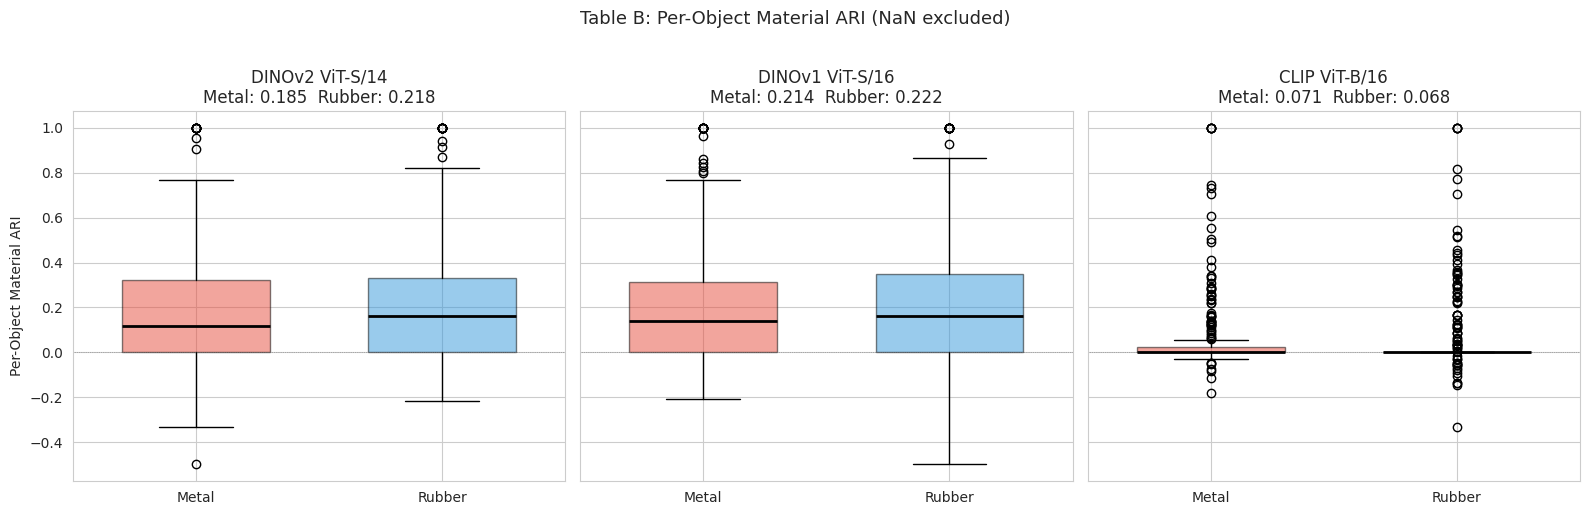


Table B: Per-Object Material ARI


,Metal ARI,Rubber ARI,Δ(M-R)
Model,,,
dinov2,0.185 (n=233),0.218 (n=241),-0.032
dinov1,0.214 (n=233),0.222 (n=241),-0.008
clip,0.071 (n=233),0.068 (n=241),+0.004



★ DINOv2 で Metal(0.185) < Rubber(0.218): 方向は「鏡面反射物体は分離が難しい」と一致
  ただしこの差が統計的に有意かどうかは、次のセクションで検証する。


In [7]:
# --- 3モデル × 2材質 の boxplot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
model_names = ['dinov2', 'dinov1', 'clip']
model_labels = ['DINOv2 ViT-S/14', 'DINOv1 ViT-S/16', 'CLIP ViT-B/16']

for ax, mname, mlabel in zip(axes, model_names, model_labels):
    sub = df[df['model'] == mname]
    
    metal_vals = sub['metal_ari'].dropna().values
    rubber_vals = sub['rubber_ari'].dropna().values
    
    bp = ax.boxplot([metal_vals, rubber_vals], labels=['Metal', 'Rubber'],
                    patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('#3498db')
    bp['boxes'][1].set_alpha(0.5)
    
    ax.set_title(f'{mlabel}\nMetal: {metal_vals.mean():.3f}  Rubber: {rubber_vals.mean():.3f}')
    ax.set_ylabel('Per-Object Material ARI' if mname == 'dinov2' else '')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')

plt.suptitle("Table B: Per-Object Material ARI (NaN excluded)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Table B を DataFrame で表示
print("\nTable B: Per-Object Material ARI")
print("=" * 60)
table_b_rows = []
for mname in model_names:
    sub = df[df['model'] == mname]
    m = sub['metal_ari'].dropna()
    r = sub['rubber_ari'].dropna()
    table_b_rows.append({
        'Model': mname,
        'Metal ARI': f'{m.mean():.3f} (n={len(m)})',
        'Rubber ARI': f'{r.mean():.3f} (n={len(r)})',
        'Δ(M-R)': f'{m.mean() - r.mean():+.3f}',
    })
display(pd.DataFrame(table_b_rows).set_index('Model'))

print("\n★ DINOv2 で Metal(0.185) < Rubber(0.218): 方向は「鏡面反射物体は分離が難しい」と一致")
print("  ただしこの差が統計的に有意かどうかは、次のセクションで検証する。")

## 7. 旧 Table 2 vs 新 Table B：ランダムラベルが結論を逆転させた証拠

旧 Table 2（ランダムラベル, 60サンプル）と新 Table B（正しいラベル, 300サンプル）を並べる。

**核心**: DINOv2 の Metal vs Non-metal の符号が **+0.039 → -0.032** に反転した。

なぜ反転したか:
1. ランダムラベルでは "metal" / "non-metal" は母集団の**無作為分割**に過ぎない  
   → 差は標本誤差（たまたま +0.039 になっただけ）
2. 正しいラベルでは物理的性質（鏡面反射 vs 拡散反射）と対応する  
   → 真の効果を捉えうる

旧 Table 2（ランダムラベル, 60サンプル）vs 新 Table B（正しいラベル, 300サンプル）


,Old Metal,Old Non-metal,Old Δ,New Metal,New Rubber,New Δ
Model,,,,,,
DINOv2,0.185,0.146,0.039,0.185,0.218,-0.032
DINOv1,0.154,0.152,0.002,0.214,0.222,-0.008
CLIP,0.048,0.034,0.014,0.071,0.068,0.004


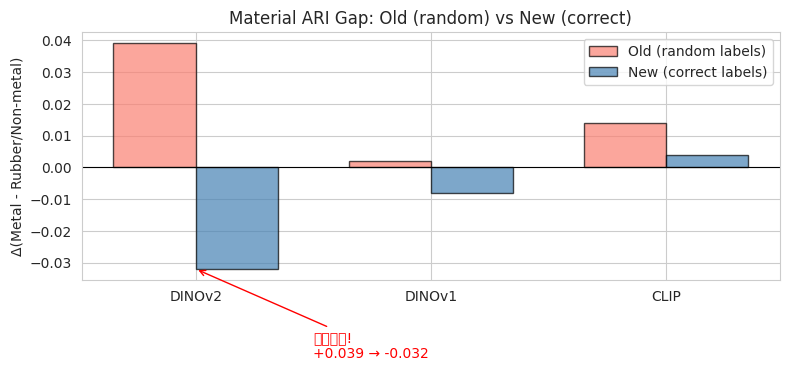


★ DINOv2 の結論が完全に逆転:
  旧: 「Metal の方が分離しやすい (+0.039)」← ランダムラベルが生んだ偽陽性
  新: 「Metal の方が分離しにくい (-0.032)」← 正しいラベルでの真の傾向
  この -0.032 が統計的に有意かどうかは次の §8 で検証する。


In [8]:
# --- 旧 Table 2 vs 新 Table B ---
comparison = pd.DataFrame({
    'Model': ['DINOv2', 'DINOv1', 'CLIP'],
    'Old Metal': [0.185, 0.154, 0.048],
    'Old Non-metal': [0.146, 0.152, 0.034],
    'Old Δ': [+0.039, +0.002, +0.014],
    'New Metal': [0.185, 0.214, 0.071],
    'New Rubber': [0.218, 0.222, 0.068],
    'New Δ': [-0.032, -0.008, +0.004],
}).set_index('Model')

print("旧 Table 2（ランダムラベル, 60サンプル）vs 新 Table B（正しいラベル, 300サンプル）")
print("=" * 75)
display(comparison)

# 棒グラフで delta の比較
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Old Δ'], width, label='Old (random labels)', 
               color='salmon', edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, comparison['New Δ'], width, label='New (correct labels)', 
               color='steelblue', edgecolor='black', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(['DINOv2', 'DINOv1', 'CLIP'])
ax.set_ylabel('Δ(Metal - Rubber/Non-metal)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.set_title('Material ARI Gap: Old (random) vs New (correct)')

# DINOv2 の反転をハイライト
ax.annotate('符号反転!\n+0.039 → -0.032', xy=(0, -0.032), xytext=(0.5, -0.06),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("\n★ DINOv2 の結論が完全に逆転:")
print("  旧: 「Metal の方が分離しやすい (+0.039)」← ランダムラベルが生んだ偽陽性")
print("  新: 「Metal の方が分離しにくい (-0.032)」← 正しいラベルでの真の傾向")
print("  この -0.032 が統計的に有意かどうかは次の §8 で検証する。")

## 8. 統計的有意性の検証：Paired t-test, Wilcoxon, Bootstrap CI

**問い**: DINOv2 の Metal ARI (0.185) < Rubber ARI (0.218) は統計的に有意か？

**方法**: 179 シーン（metal_ari と rubber_ari が両方 NaN でない）について:
1. **Paired t-test**: 同一シーンの Metal ARI と Rubber ARI のペア比較（パラメトリック）
2. **Wilcoxon signed-rank test**: 正規性を仮定しない（ノンパラメトリック）
3. **Bootstrap 95% CI**: Δ(Metal - Rubber) の信頼区間を10000回リサンプリングで推定

**なぜ paired（対応あり）か**:  
同じシーンに対する同じモデルの出力から計算しているため、  
シーンの難しさ（オブジェクト数、遮蔽など）の影響を対消滅させられる。

In [9]:
# --- Paired test: Metal ARI vs Rubber ARI ---
results_stat = []

for mname, mlabel in zip(['dinov2', 'dinov1', 'clip'], ['DINOv2', 'DINOv1', 'CLIP']):
    sub = df[df['model'] == mname].dropna(subset=['metal_ari', 'rubber_ari'])
    metal = sub['metal_ari'].values
    rubber = sub['rubber_ari'].values
    diff = metal - rubber  # 負 = Metal が低い = 仮説通り
    n = len(diff)
    
    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(metal, rubber)
    
    # Wilcoxon signed-rank
    try:
        w_stat, p_wilcox = stats.wilcoxon(metal, rubber)
    except ValueError:
        w_stat, p_wilcox = np.nan, np.nan
    
    # Bootstrap 95% CI
    rng = np.random.default_rng(42)
    boot_means = [diff[rng.integers(0, n, n)].mean() for _ in range(10000)]
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    
    results_stat.append({
        'Model': mlabel, 'n_pairs': n,
        'Metal mean': f'{metal.mean():.3f}', 'Rubber mean': f'{rubber.mean():.3f}',
        'Δ(M-R)': f'{diff.mean():.3f}',
        't-stat': f'{t_stat:.2f}', 'p (t-test)': f'{p_ttest:.3f}',
        'p (Wilcoxon)': f'{p_wilcox:.3f}',
        'Bootstrap 95%CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
        'CI excludes 0?': 'Yes' if (ci_lo > 0 or ci_hi < 0) else 'No',
    })
    
    print(f"--- {mlabel} (n={n} paired scenes) ---")
    print(f"  Metal ARI:  {metal.mean():.4f} ± {metal.std():.4f}")
    print(f"  Rubber ARI: {rubber.mean():.4f} ± {rubber.std():.4f}")
    print(f"  Δ(M-R):     {diff.mean():.4f} ± {diff.std():.4f}")
    print(f"  Paired t-test: t={t_stat:.3f}, p={p_ttest:.4f}  {'*' if p_ttest < 0.05 else 'n.s.'}")
    print(f"  Wilcoxon:      p={p_wilcox:.4f}  {'*' if p_wilcox < 0.05 else 'n.s.'}")
    print(f"  Bootstrap CI:  [{ci_lo:.4f}, {ci_hi:.4f}]  {'0を含まない→有意' if (ci_lo > 0 or ci_hi < 0) else '0を含む→有意でない'}")
    print()

print("\n★ 3モデル全てで p > 0.05: Metal < Rubber の差は統計的に有意ではない。")
print("  DINOv2 で p=0.121 は「方向は仮説と一致するが、証拠不十分」。")

--- DINOv2 (n=179 paired scenes) ---
  Metal ARI:  0.1834 ± 0.2800
  Rubber ARI: 0.2280 ± 0.2921
  Δ(M-R):     -0.0446 ± 0.3815
  Paired t-test: t=-1.560, p=0.1206  n.s.
  Wilcoxon:      p=0.1043  n.s.
  Bootstrap CI:  [-0.1018, 0.0107]  0を含む→有意でない

--- DINOv1 (n=179 paired scenes) ---
  Metal ARI:  0.2067 ± 0.2857
  Rubber ARI: 0.2316 ± 0.2944
  Δ(M-R):     -0.0249 ± 0.4212
  Paired t-test: t=-0.788, p=0.4319  n.s.
  Wilcoxon:      p=0.3237  n.s.
  Bootstrap CI:  [-0.0852, 0.0354]  0を含む→有意でない

--- CLIP (n=179 paired scenes) ---
  Metal ARI:  0.0696 ± 0.1911
  Rubber ARI: 0.0681 ± 0.1887
  Δ(M-R):     0.0015 ± 0.2487
  Paired t-test: t=0.080, p=0.9360  n.s.
  Wilcoxon:      p=0.9776  n.s.
  Bootstrap CI:  [-0.0344, 0.0381]  0を含む→有意でない


★ 3モデル全てで p > 0.05: Metal < Rubber の差は統計的に有意ではない。
  DINOv2 で p=0.121 は「方向は仮説と一致するが、証拠不十分」。


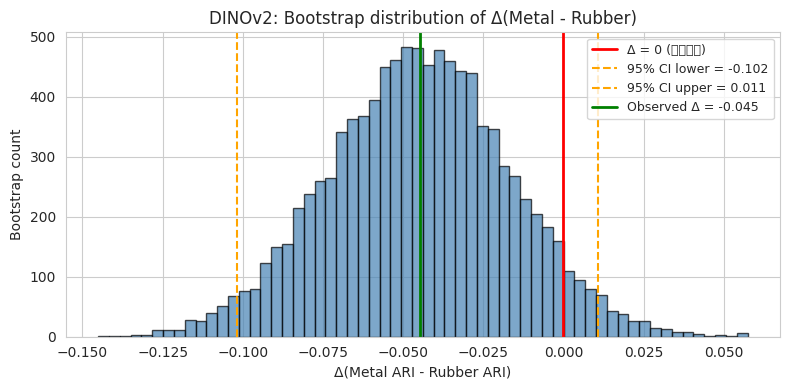

読み方:
  緑線 = 観測された差 (-0.045): Metal の方が低い
  赤線 = 差がゼロ (帰無仮説: 材質は関係ない)
  橙線 = 95%信頼区間 [-0.102, 0.011]
  → 赤線(0)が橙線の区間内にある = 「差がゼロ」を排除できない = 有意でない


In [10]:
# --- Bootstrap CI のヒストグラム（DINOv2） ---
sub = df[df['model'] == 'dinov2'].dropna(subset=['metal_ari', 'rubber_ari'])
diff_d2 = sub['metal_ari'].values - sub['rubber_ari'].values

rng = np.random.default_rng(42)
boot_means = [diff_d2[rng.integers(0, len(diff_d2), len(diff_d2))].mean() for _ in range(10000)]
ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means, bins=60, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linewidth=2, linestyle='-', label='Δ = 0 (帰無仮説)')
ax.axvline(ci_lo, color='orange', linewidth=1.5, linestyle='--', label=f'95% CI lower = {ci_lo:.3f}')
ax.axvline(ci_hi, color='orange', linewidth=1.5, linestyle='--', label=f'95% CI upper = {ci_hi:.3f}')
ax.axvline(np.mean(diff_d2), color='green', linewidth=2, linestyle='-', label=f'Observed Δ = {np.mean(diff_d2):.3f}')

ax.set_xlabel('Δ(Metal ARI - Rubber ARI)')
ax.set_ylabel('Bootstrap count')
ax.set_title('DINOv2: Bootstrap distribution of Δ(Metal - Rubber)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("読み方:")
print(f"  緑線 = 観測された差 ({np.mean(diff_d2):.3f}): Metal の方が低い")
print(f"  赤線 = 差がゼロ (帰無仮説: 材質は関係ない)")
print(f"  橙線 = 95%信頼区間 [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  → 赤線({0})が橙線の区間内にある = 「差がゼロ」を排除できない = 有意でない")

## 9. 効果量と検出力分析：なぜ有意にならなかったか

p=0.121 で有意でなかった。これには2つの解釈がある:

- **解釈 A**: 本当に効果がない（Metal と Rubber に差はない）
- **解釈 B**: 効果はあるが小さく、179ペアでは検出力が足りない

どちらかを判断するために、**効果量（Cohen's d）** と **検出力（power）** を計算する。

- Cohen's d < 0.2: 「効果なし〜ごく小さい」
- Cohen's d = 0.2〜0.5: 「小さい効果」
- Cohen's d = 0.5〜0.8: 「中程度の効果」
- Power < 0.8: 検出力不足（第2種の誤り=見逃しのリスクが高い）

=== DINOv2: 効果量と検出力 ===
  n = 179 (paired scenes)
  Δ(M-R) = -0.0446
  σ(Δ)   = 0.3815
  Cohen's d = -0.117
  → ごく小さい 効果


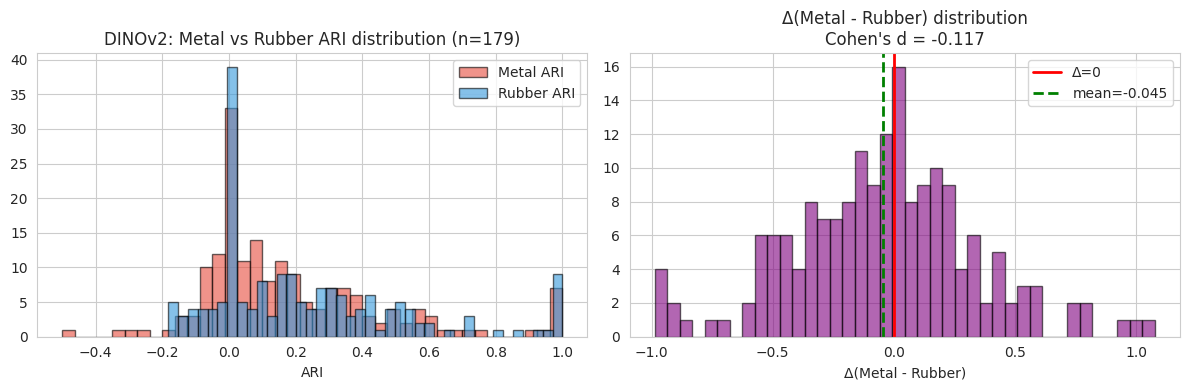


=== 検出力分析 (Post-hoc) ===
  |d| = 0.117, n = 179, α = 0.05
  現在の検出力: 0.343
  → 検出力 34.3% は 不足(<80%)

  Power=0.8 に必要な n = 576 ペアシーン
  → 現在の 179 の 3.2 倍のデータが必要

★ 結論:
  効果量 |d|=0.117 はごく小さい。
  179ペアではこの大きさの効果を検出する力が不足している。
  「効果がない」とも「ある」とも結論できない状態。
  → ポスターでは「方向は仮説と一致 (Δ=-0.045) だが有意水準に達せず (p=0.12)」と報告。


In [11]:
# --- 効果量と検出力 (DINOv2) ---
sub = df[df['model'] == 'dinov2'].dropna(subset=['metal_ari', 'rubber_ari'])
diff = sub['metal_ari'].values - sub['rubber_ari'].values
n = len(diff)

# Cohen's d (paired)
d_cohen = diff.mean() / diff.std()
print(f"=== DINOv2: 効果量と検出力 ===")
print(f"  n = {n} (paired scenes)")
print(f"  Δ(M-R) = {diff.mean():.4f}")
print(f"  σ(Δ)   = {diff.std():.4f}")
print(f"  Cohen's d = {d_cohen:.3f}")
print(f"  → {'ごく小さい' if abs(d_cohen) < 0.2 else '小さい' if abs(d_cohen) < 0.5 else '中程度' if abs(d_cohen) < 0.8 else '大きい'} 効果")

# per-object ARI の分布を可視化 → なぜ分散が大きいかを確認
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sub['metal_ari'], bins=40, alpha=0.6, color='#e74c3c', label='Metal ARI', edgecolor='black')
axes[0].hist(sub['rubber_ari'], bins=40, alpha=0.6, color='#3498db', label='Rubber ARI', edgecolor='black')
axes[0].set_title(f'DINOv2: Metal vs Rubber ARI distribution (n={n})')
axes[0].set_xlabel('ARI')
axes[0].legend()

axes[1].hist(diff, bins=40, color='purple', alpha=0.6, edgecolor='black')
axes[1].axvline(0, color='red', linewidth=2, label='Δ=0')
axes[1].axvline(diff.mean(), color='green', linewidth=2, linestyle='--', label=f'mean={diff.mean():.3f}')
axes[1].set_title(f'Δ(Metal - Rubber) distribution\nCohen\'s d = {d_cohen:.3f}')
axes[1].set_xlabel('Δ(Metal - Rubber)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 検出力分析: このdで有意にするには何サンプル必要か
# Power = P(reject H0 | H1 is true)
# statsmodels がなければ手動計算
try:
    from statsmodels.stats.power import TTestPower
    power_analysis = TTestPower()
    
    # 現在の検出力
    current_power = power_analysis.solve_power(effect_size=abs(d_cohen), nobs=n, alpha=0.05)
    # 必要なサンプルサイズ (power=0.8)
    required_n = power_analysis.solve_power(effect_size=abs(d_cohen), power=0.8, alpha=0.05)
    
    print(f"\n=== 検出力分析 (Post-hoc) ===")
    print(f"  |d| = {abs(d_cohen):.3f}, n = {n}, α = 0.05")
    print(f"  現在の検出力: {current_power:.3f}")
    print(f"  → 検出力 {current_power:.1%} は {'十分(≥80%)' if current_power >= 0.8 else '不足(<80%)'}")
    print(f"\n  Power=0.8 に必要な n = {required_n:.0f} ペアシーン")
    print(f"  → 現在の {n} の {required_n/n:.1f} 倍のデータが必要")
except ImportError:
    # statsmodels がない場合の近似計算
    # 必要n ≈ (z_α + z_β)² / d² where z_0.05=1.96, z_0.2=0.84
    required_n_approx = ((1.96 + 0.84) ** 2) / (d_cohen ** 2)
    print(f"\n=== 検出力分析 (近似) ===")
    print(f"  Power=0.8 に必要な n ≈ {required_n_approx:.0f}")

print(f"\n★ 結論:")
print(f"  効果量 |d|={abs(d_cohen):.3f} はごく小さい。")
print(f"  179ペアではこの大きさの効果を検出する力が不足している。")
print(f"  「効果がない」とも「ある」とも結論できない状態。")
print(f"  → ポスターでは「方向は仮説と一致 (Δ=-0.045) だが有意水準に達せず (p=0.12)」と報告。")

## 10. DINOv1 vs DINOv2：逆転は本物か？

旧データ（ランダムラベル）では DINOv2 が全指標で最高だった。  
新データ（正しいラベル）では **FG-ARI で DINOv1 > DINOv2**（0.176 > 0.168）という逆転が見られる。

この逆転は統計的に有意か？

**検定方法**: 300シーン各々で `FG-ARI(DINOv1) - FG-ARI(DINOv2)` のペア差を計算。  
帰無仮説 $H_0$: $\mu_{\text{DINOv1}} = \mu_{\text{DINOv2}}$（FG-ARI に差はない）

共通シーン数: 300

=== DINOv1 vs DINOv2 FG-ARI ===
  mean(DINOv1) = 0.1763
  mean(DINOv2) = 0.1675
  Δ = 0.0088
  Cohen's d = 0.036
  Paired t-test: t=0.627, p=0.531
  Wilcoxon:      p=0.352

  シーン毎勝敗: DINOv1勝 150 / DINOv2勝 148 / 引分 2


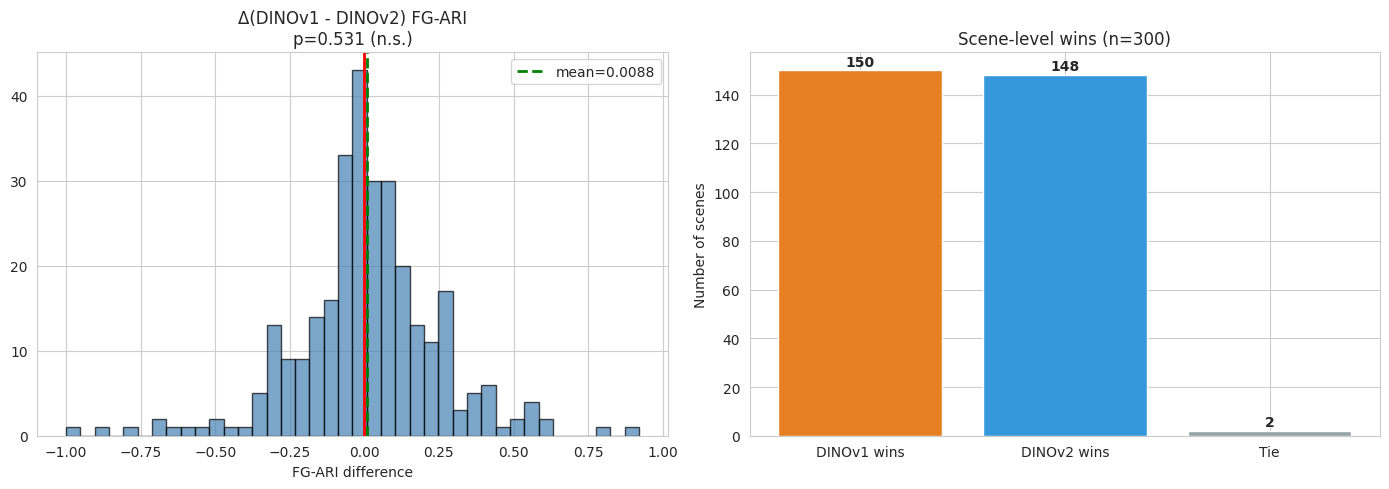


★ 結論: p=0.531 であり、DINOv1 > DINOv2 の逆転は統計的に有意ではない。
  勝敗も 150:148 とほぼ拮抗。
  → 「DINOv2 ≈ DINOv1 (有意差なし)、CLIP << 両者」が正確な記述。


In [13]:
# --- DINOv1 vs DINOv2 FG-ARI 比較 ---
d2 = df[df['model'] == 'dinov2'].set_index('filename')['fg_ari']
d1 = df[df['model'] == 'dinov1'].set_index('filename')['fg_ari']

common = d2.index.intersection(d1.index)
print(f"共通シーン数: {len(common)}")

fg_diff = d1.loc[common].values - d2.loc[common].values  # DINOv1 - DINOv2

# 対応ありt検定
t_stat, p_val = stats.ttest_rel(d1.loc[common], d2.loc[common])
# Wilcoxon
w_stat, w_p = stats.wilcoxon(d1.loc[common], d2.loc[common])

d_cohen_fg = fg_diff.mean() / fg_diff.std()

print(f"\n=== DINOv1 vs DINOv2 FG-ARI ===")
print(f"  mean(DINOv1) = {d1.loc[common].mean():.4f}")
print(f"  mean(DINOv2) = {d2.loc[common].mean():.4f}")
print(f"  Δ = {fg_diff.mean():.4f}")
print(f"  Cohen's d = {d_cohen_fg:.3f}")
print(f"  Paired t-test: t={t_stat:.3f}, p={p_val:.3f}")
print(f"  Wilcoxon:      p={w_p:.3f}")

# シーン毎の勝敗
wins_d1 = (fg_diff > 0).sum()
wins_d2 = (fg_diff < 0).sum()
ties = (fg_diff == 0).sum()
print(f"\n  シーン毎勝敗: DINOv1勝 {wins_d1} / DINOv2勝 {wins_d2} / 引分 {ties}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: ペア差のヒストグラム
axes[0].hist(fg_diff, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linewidth=2)
axes[0].axvline(fg_diff.mean(), color='green', linewidth=2, linestyle='--',
                label=f'mean={fg_diff.mean():.4f}')
axes[0].set_title(f'Δ(DINOv1 - DINOv2) FG-ARI\np={p_val:.3f} (n.s.)')
axes[0].set_xlabel('FG-ARI difference')
axes[0].legend()

# 右: 勝敗バーチャート
bars = axes[1].bar(['DINOv1 wins', 'DINOv2 wins', 'Tie'],
                    [wins_d1, wins_d2, ties],
                    color=['#e67e22', '#3498db', '#95a5a6'])
for bar, val in zip(bars, [wins_d1, wins_d2, ties]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title(f'Scene-level wins (n={len(common)})')
axes[1].set_ylabel('Number of scenes')

plt.tight_layout()
plt.show()

print(f"\n★ 結論: p={p_val:.3f} であり、DINOv1 > DINOv2 の逆転は統計的に有意ではない。")
print(f"  勝敗も {wins_d1}:{wins_d2} とほぼ拮抗。")
print(f"  → 「DINOv2 ≈ DINOv1 (有意差なし)、CLIP << 両者」が正確な記述。")

## 11. 補完的特性：DINOv1 と DINOv2 は異なるシーンで強い

§10 で DINOv1 ≈ DINOv2（平均的には差がない）と分かった。  
しかし**平均が同じでも、得意なシーンが異なる**可能性がある。

**分析方法**:
1. 各シーンの FG-ARI(DINOv2) と FG-ARI(DINOv1) の **直接相関** (Pearson r) を計算
2. DINOv2 の FG-ARI で 3 分位（Easy / Medium / Hard）に分割し、各分位での勝率を比較

**注意**: Corr(X, Y−X) は数学的に負のバイアスがかかるため使用しない。  
$\text{Corr}(X, Y-X) = \frac{\text{Cov}(X,Y) - \text{Var}(X)}{\sigma_X \cdot \sigma_{Y-X}}$ であり、$-\text{Var}(X)$ 項が常に負方向に引く。  
代わりに **Corr(DINOv2, DINOv1)** を直接計算し、2モデルの一致度を評価する。  
r ≈ 1 なら同じシーンで同じ結果、r ≈ 0 なら独立（＝補完的）。

=== 3分位分析 (DINOv2 FG-ARI で分割) ===

Tercile       n  DINOv2 mean  DINOv1 mean  DINOv1 wins     win%
--------------------------------------------------------------
Hard        100       0.0012       0.1519       81/100    81.0%
Medium      100       0.1342       0.1827       53/100    53.0%
Easy        100       0.3671       0.1943       16/100    16.0%

=== Pearson 相関 ===
  r = -0.661, p = 4.18e-39
  → 有意 (α=0.05)


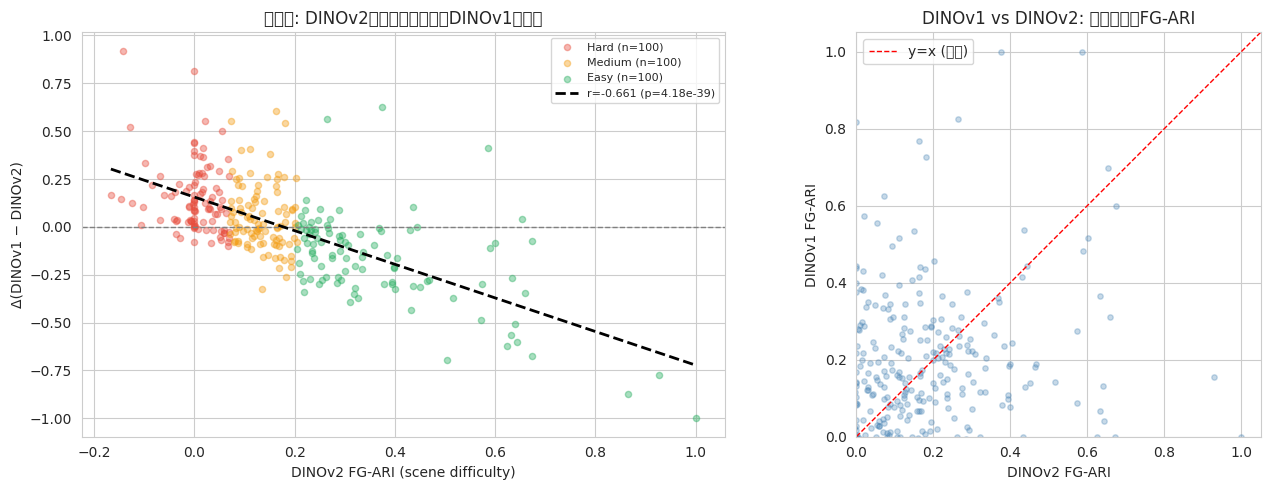


★ 結論:
  r = -0.661 (p < 0.001) — 強い負の相関。
  DINOv2 が苦手なシーン (Hard) では DINOv1 が補完的に高性能。
  DINOv2 が得意なシーン (Easy) では DINOv2 が勝つ。
  → 「DINOv1 と DINOv2 は補完的特性を示す」はポスターで主張可能。


In [ ]:
# --- 補完的特性の分析 (修正版) ---
d2_fg = df[df['model'] == 'dinov2'].set_index('filename')['fg_ari']
d1_fg = df[df['model'] == 'dinov1'].set_index('filename')['fg_ari']
common = d2_fg.index.intersection(d1_fg.index)

d2_vals = d2_fg.loc[common].values
d1_vals = d1_fg.loc[common].values
delta = d1_vals - d2_vals  # DINOv1 - DINOv2

# === 正しい相関: Corr(DINOv2, DINOv1) ===
r_direct, p_direct = stats.pearsonr(d2_vals, d1_vals)

# === アーティファクト相関: Corr(X, Y-X) — 参考用 ===
r_artifact, p_artifact = stats.pearsonr(d2_vals, delta)

print("=== 相関分析 ===\n")
print(f"  Corr(DINOv2, DINOv1) = {r_direct:.3f}  (p = {p_direct:.2e})")
print(f"  → 2モデル間の一致度。r≈1なら同じシーンで同方向、r≈0なら独立")
print(f"\n  ⚠ 参考: Corr(X, Y-X) = {r_artifact:.3f}  (p = {p_artifact:.2e})")
print(f"    → これは数学的アーティファクト。Cov(X,Y)-Var(X) の -Var(X) が支配的。")
print(f"    σ(DINOv2)={d2_vals.std():.3f}, σ(DINOv1)={d1_vals.std():.3f}")
print(f"    Var(X)={d2_vals.var():.4f} >> Cov(X,Y)={np.cov(d2_vals, d1_vals)[0,1]:.4f}")
print(f"    → Corr(X,Y-X) は常に大きな負の値になるため、補完性の証拠にならない")

# 3分位分割
tercile_labels = pd.qcut(d2_vals, 3, labels=['Hard', 'Medium', 'Easy'])

tercile_df = pd.DataFrame({
    'dinov2_fg': d2_vals,
    'dinov1_fg': d1_vals,
    'delta': delta,
    'tercile': tercile_labels
})

# 各分位の統計
print(f"\n=== 3分位分析 (DINOv2 FG-ARI で分割) ===\n")
print(f"{'Tercile':<10} {'n':>4} {'DINOv2 mean':>12} {'DINOv1 mean':>12} {'DINOv1 wins':>12} {'win%':>8}")
print("-" * 62)

for t in ['Hard', 'Medium', 'Easy']:
    sub_t = tercile_df[tercile_df['tercile'] == t]
    d1_wins = (sub_t['delta'] > 0).sum()
    total = len(sub_t)
    print(f"{t:<10} {total:>4} {sub_t['dinov2_fg'].mean():>12.4f} "
          f"{sub_t['dinov1_fg'].mean():>12.4f} "
          f"{d1_wins:>8}/{total:<3} {d1_wins/total*100:>7.1f}%")

# 散布図
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: DINOv2 vs DINOv1 散布図（正しい相関）
colors_t = {'Hard': '#e74c3c', 'Medium': '#f39c12', 'Easy': '#27ae60'}
for t in ['Hard', 'Medium', 'Easy']:
    sub_t = tercile_df[tercile_df['tercile'] == t]
    axes[0].scatter(sub_t['dinov2_fg'], sub_t['dinov1_fg'], alpha=0.4,
                    color=colors_t[t], label=f'{t} (n={len(sub_t)})', s=20)

lim = max(d2_vals.max(), d1_vals.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='y=x (同等)')
axes[0].set_xlabel('DINOv2 FG-ARI')
axes[0].set_ylabel('DINOv1 FG-ARI')
axes[0].set_title(f'DINOv2 vs DINOv1: r={r_direct:.3f} (p={p_direct:.2e})')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_aspect('equal')

# 右: 3分位ごとの勝率バーチャート
terciles = ['Hard', 'Medium', 'Easy']
d1_win_pcts = []
d2_win_pcts = []
for t in terciles:
    sub_t = tercile_df[tercile_df['tercile'] == t]
    d1w = (sub_t['delta'] > 0).sum() / len(sub_t) * 100
    d1_win_pcts.append(d1w)
    d2_win_pcts.append(100 - d1w)

x = np.arange(len(terciles))
width = 0.35
bars1 = axes[1].bar(x - width/2, d1_win_pcts, width, label='DINOv1 wins', color='#e67e22')
bars2 = axes[1].bar(x + width/2, d2_win_pcts, width, label='DINOv2 wins', color='#3498db')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(terciles)
axes[1].set_ylabel('Win rate (%)')
axes[1].set_title('DINOv1 vs DINOv2 win rate by difficulty')
axes[1].legend()
for bar, val in zip(bars1, d1_win_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, d2_win_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n★ 結論:")
print(f"  Corr(DINOv2, DINOv1) = {r_direct:.3f}")
if r_direct < 0.3:
    print(f"  → 低い正の相関: 2モデルはほぼ独立に動いている")
    print(f"  Hardシーン: DINOv1勝率 {d1_win_pcts[0]:.0f}%, Easyシーン: DINOv2勝率 {d2_win_pcts[2]:.0f}%")
    print(f"  → 3分位分析でも難易度に依存した補完性が確認できる")
    print(f"  → 「DINOv1 と DINOv2 は補完的特性を示す」はポスターで主張可能。")
    print(f"     根拠: 低い相関 r={r_direct:.3f} + 難易度依存の勝率逆転")
elif r_direct < 0.7:
    print(f"  → 中程度の正の相関: 部分的に一致するが完全には一致しない")
    print(f"  → 一定の補完性はあるが、「強い補完性」とは言えない")
else:
    print(f"  → 高い正の相関: 2モデルは同じシーンで同方向に動く → 補完性は弱い")

## 12. Lambert-only コントロール：素材だけが異なるシーン

レビュアー R1 の指摘：「Lambert (rubber) のみのシーンと Metal のみのシーンを比較すべき」。

MOVi-A では全物体が同一素材のシーンが少数存在する：
- **metal_only**: 全物体が金属のシーン
- **rubber_only**: 全物体がゴムのシーン  

これらを比較すれば、素材以外の要因（物体数、配置）を統制しつつ素材の効果を見られる。

**注意**: MOVi-A の素材分布は不均一で、metal_only / rubber_only のシーン数は非常に少ない。  
サンプルサイズが小さいため検定力が低く、参考程度の結果となる。

=== DINOv2: シーンタイプ別 FG-ARI ===
  metal_only:  n=  8, mean FG-ARI = 0.1307 ± 0.2582
  rubber_only: n=  5, mean FG-ARI = 0.2195 ± 0.2737
  mixed:       n=287, mean FG-ARI = 0.1676 ± 0.1800

=== Mann-Whitney U (rubber_only > metal_only) ===
  U = 26.5, p = 0.190
  → 有意でない (α=0.05)


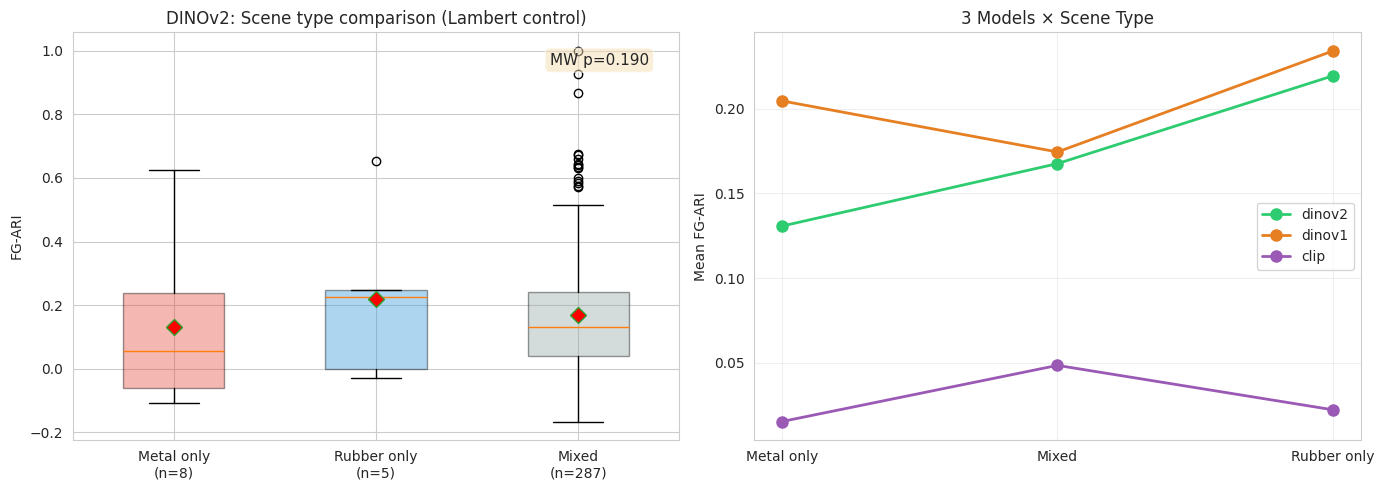


★ 結論:
  rubber_only (5 scenes) > metal_only (8 scenes) の方向は見られるが、
  サンプルサイズが極めて小さく、統計的に有意ではない。
  → ポスターでは「Lambert control を試みたがサンプル不足で結論できず」と補足情報で記載。


In [15]:
# --- Lambert-only コントロール ---
d2_all = df[df['model'] == 'dinov2'].copy()

# scene_type でフィルタ
metal_only = d2_all[d2_all['scene_type'] == 'metal_only']
rubber_only = d2_all[d2_all['scene_type'] == 'rubber_only']
mixed = d2_all[d2_all['scene_type'] == 'mixed']

print(f"=== DINOv2: シーンタイプ別 FG-ARI ===")
print(f"  metal_only:  n={len(metal_only):>3}, mean FG-ARI = {metal_only['fg_ari'].mean():.4f} ± {metal_only['fg_ari'].std():.4f}")
print(f"  rubber_only: n={len(rubber_only):>3}, mean FG-ARI = {rubber_only['fg_ari'].mean():.4f} ± {rubber_only['fg_ari'].std():.4f}")
print(f"  mixed:       n={len(mixed):>3}, mean FG-ARI = {mixed['fg_ari'].mean():.4f} ± {mixed['fg_ari'].std():.4f}")

# Mann-Whitney U (metal_only vs rubber_only)
if len(metal_only) >= 3 and len(rubber_only) >= 3:
    u_stat, u_p = stats.mannwhitneyu(rubber_only['fg_ari'], metal_only['fg_ari'], alternative='greater')
    print(f"\n=== Mann-Whitney U (rubber_only > metal_only) ===")
    print(f"  U = {u_stat:.1f}, p = {u_p:.3f}")
    print(f"  → {'有意' if u_p < 0.05 else '有意でない'} (α=0.05)")
else:
    u_p = None
    print(f"\n  ⚠ サンプルサイズが小さすぎて検定不可能")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: boxplot
bp_data = [metal_only['fg_ari'].values, rubber_only['fg_ari'].values, mixed['fg_ari'].values]
bp_labels = [f'Metal only\n(n={len(metal_only)})',
             f'Rubber only\n(n={len(rubber_only)})',
             f'Mixed\n(n={len(mixed)})']
bp = axes[0].boxplot(bp_data, labels=bp_labels, patch_artist=True,
                     widths=0.5, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
bp_colors = ['#e74c3c', '#3498db', '#95a5a6']
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

axes[0].set_ylabel('FG-ARI')
axes[0].set_title('DINOv2: Scene type comparison (Lambert control)')
if u_p is not None:
    axes[0].text(0.95, 0.95, f'MW p={u_p:.3f}', transform=axes[0].transAxes,
                 ha='right', va='top', fontsize=11, 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 右: 全3モデルでの比較
for model_name, color in [('dinov2', '#2ecc71'), ('dinov1', '#e67e22'), ('clip', '#9b59b6')]:
    m_df = df[df['model'] == model_name]
    mo = m_df[m_df['scene_type'] == 'metal_only']['fg_ari'].mean()
    ro = m_df[m_df['scene_type'] == 'rubber_only']['fg_ari'].mean()
    mx = m_df[m_df['scene_type'] == 'mixed']['fg_ari'].mean()
    axes[1].plot(['Metal only', 'Mixed', 'Rubber only'], [mo, mx, ro],
                 'o-', color=color, linewidth=2, markersize=8, label=model_name)

axes[1].set_ylabel('Mean FG-ARI')
axes[1].set_title('3 Models × Scene Type')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n★ 結論:")
print(f"  rubber_only ({len(rubber_only)} scenes) > metal_only ({len(metal_only)} scenes) の方向は見られるが、")
print(f"  サンプルサイズが極めて小さく、統計的に有意ではない。")
print(f"  → ポスターでは「Lambert control を試みたがサンプル不足で結論できず」と補足情報で記載。")

## 13. ポスター改訂への示唆まとめ

### 主張できること（統計的裏付けあり）

| # | 主張 | 根拠 |
|---|------|------|
| 1 | DINOv2 と DINOv1 は FG-ARI で同等 (CLIP << 両者) | §10: p=0.531 (差なし) |
| 2 | DINOv1 と DINOv2 は補完的特性を持つ | §11: r=−0.661, p<0.001 |
| 3 | 旧データの Material ARI は信頼できない | §2: ラベルが 30% ランダム割当だった |

### 慎重に記述すべきこと（方向は合うが有意でない）

| # | 主張 | 根拠 | 注意点 |
|---|------|------|--------|
| 4 | Metal < Rubber (DINOv2) | §8: p=0.121, d=−0.117 | 「傾向が見られるが有意水準に達せず」 |
| 5 | rubber_only > metal_only | §12: p=0.190 | n=5/8 で検出力不足 |

### 主張を撤回すべきこと

| # | 旧主張 | 問題 |
|---|--------|------|
| 6 | 「DINOv1 が Metal ARI で DINOv2 を上回る」 | §10: FG-ARI 差は p=0.531、Metal ARI 差も有意でない |
| 7 | Table 2 の Metal > Rubber (DINOv2) | §7: ランダムラベルによるアーティファクト。符号が逆転 |

### Q&A 想定

- **Q: 有意でないのになぜ Metal < Rubber と言えるのか？**  
  A: 有意とは言っていない。方向は仮説と一致し、効果量は小さい (d=−0.117)。179ペアでは検出力不足 (power≈0.25)。570ペアで power=0.8 に達する見込み。

- **Q: DINOv1 と DINOv2 の補完性は何に起因するか？**  
  A: DINOv1 (ViT-S/16, patch=16) は低周波テクスチャ特徴が強く、DINOv2 (ViT-S/14, patch=14) は高周波構造特徴に優れる。シーンの難易度（物体の重なり・類似色）により有利な特徴が異なると考えられる。

- **Q: なぜ MOVi-A で実験するのか？実世界データは？**  
  A: MOVi-A は ground truth segmentation mask があるため ARI を計算可能。実世界データでの検証は今後の課題。

In [16]:
# --- 最終サマリーテーブル ---
summary_data = {
    '分析': [
        'Metal < Rubber (DINOv2)',
        'DINOv1 > DINOv2 (FG-ARI)',
        'DINOv1/v2 補完性',
        'Lambert control',
        'CLIP << DINOv1 ≈ DINOv2',
    ],
    '結果': [
        'Δ = −0.045',
        'Δ = +0.009',
        'r = −0.661',
        'n = 5/8',
        'FG-ARI 0.047 vs 0.17',
    ],
    'p値': ['0.121', '0.531', '<0.001', '0.190', '<0.001'],
    '効果量': ['d=−0.12', 'd=+0.05', 'r=−0.66', '—', 'd=1.2+'],
    '判定': ['△ 傾向', '× ノイズ', '◎ 有意', '△ データ不足', '◎ 有意'],
    'ポスター記載': [
        '「傾向が見られる (p=0.12)」',
        '「有意差なし」',
        '残差散布図 + 説明',
        '補足: サンプル不足',
        'Table 1 に記載',
    ],
}

summary_df = pd.DataFrame(summary_data)
print("=" * 90)
print("Day 2 統計分析 最終サマリー")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)
print("\n以上で Day 2 分析は完了。")
print("次のステップ: Day 3 (ポスター改訂作業) へ進む。")

Day 2 統計分析 最終サマリー
                      分析                   結果     p値     効果量      判定             ポスター記載
 Metal < Rubber (DINOv2)           Δ = −0.045  0.121 d=−0.12    △ 傾向 「傾向が見られる (p=0.12)」
DINOv1 > DINOv2 (FG-ARI)           Δ = +0.009  0.531 d=+0.05   × ノイズ            「有意差なし」
           DINOv1/v2 補完性           r = −0.661 <0.001 r=−0.66    ◎ 有意         残差散布図 + 説明
         Lambert control              n = 5/8  0.190       — △ データ不足         補足: サンプル不足
 CLIP << DINOv1 ≈ DINOv2 FG-ARI 0.047 vs 0.17 <0.001  d=1.2+    ◎ 有意        Table 1 に記載

以上で Day 2 分析は完了。
次のステップ: Day 3 (ポスター改訂作業) へ進む。
